<a href="https://colab.research.google.com/github/DantDesign/ecommerce-ux-analytics/blob/main/Limpieza_An%C3%A1lisis_Visualizaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Código de Colab: Limpieza, Análisis y Visualización para UX

⚠️ DATASET ORIGINAL (CON ERRORES Y NULOS)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID_Usuario               10 non-null     int64  
 1   Dispositivo              9 non-null      object 
 2   Tiempo_Checkout_Minutos  8 non-null      float64
 3   Abandono_Carrito         10 non-null     object 
 4   Clicks_Pagina_Producto   10 non-null     int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 532.0+ bytes
None
   ID_Usuario Dispositivo  Tiempo_Checkout_Minutos Abandono_Carrito  \
0           1     Desktop                      4.5               No   
1           2      Mobile                     12.2               Si   
2           3      mobile                      NaN               Si   

   Clicks_Pagina_Producto  
0                      12  
1                      28  
2                      25  

🧹 EJECUTA

/tmp/ipykernel_1961/2160203239.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


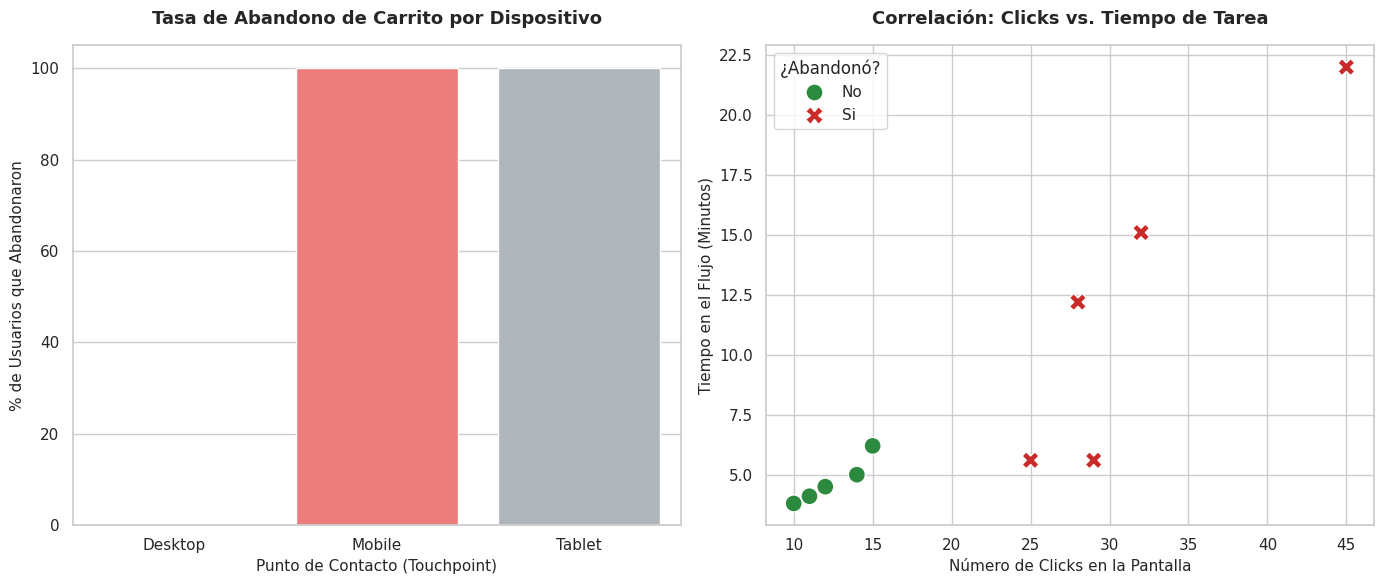

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Simulación de un Dataset "Sucio" de E-commerce (Comportamiento de Usuarios)
data = {
    'ID_Usuario': list(range(1, 11)), # Fixed: Added a list of IDs
    'Dispositivo': ['Desktop', 'Mobile', 'mobile', 'Desktop', 'Tablet', 'MOBILE', 'Desktop', None, 'Mobile', 'Desktop'],
    'Tiempo_Checkout_Minutos': [4.5, 12.2, np.nan, 3.8, 15.1, 22.0, 5.0, 4.1, np.nan, 6.2],
    'Abandono_Carrito': ['No', 'Si', 'Si', 'No', 'Si', 'Si', 'No', 'No', 'Si', 'No'],
    'Clicks_Pagina_Producto': [12, 28, 25, 10, 32, 45, 14, 11, 29, 15]
}

df_raw = pd.DataFrame(data)
print("="*60)
print("⚠️ DATASET ORIGINAL (CON ERRORES Y NULOS)")
print("="*60)
print(df_raw.info())
print(df_raw.head(3))

# 2. Fase de Limpieza de Datos (Data Cleaning)
print("\n" + "="*60)
print("🧹 EJECUTANDO PROCESO DE LIMPIEZA...")
print("="*60)

df_clean = df_raw.copy()

# A) Normalizar texto (Corregir inconsistencias como Mobile, mobile, MOBILE)
df_clean['Dispositivo'] = df_clean['Dispositivo'].str.capitalize()
# Llenar valores faltantes en dispositivo con el valor más común (Moda)
df_clean['Dispositivo'] = df_clean['Dispositivo'].fillna(df_clean['Dispositivo'].mode()[0])

# B) Tratar valores nulos en métricas cuantitativas
# Reemplazamos el tiempo de checkout nulo con la mediana para no sesgar con valores atípicos
mediana_tiempo = df_clean['Tiempo_Checkout_Minutos'].median()
df_clean['Tiempo_Checkout_Minutos'] = df_clean['Tiempo_Checkout_Minutos'].fillna(mediana_tiempo)

print("✅ Limpieza completada. Dataset listo para análisis UX.")

# 3. Análisis Estadístico Basado en UX
print("\n" + "="*60)
print("📊 ANÁLISIS DE FRICCIÓN POR DISPOSITIVO")
print("="*60)

# Agrupar datos para entender en qué pantallas se sufre más el flujo
analisis_ux = df_clean.groupby('Dispositivo').agg(
    Tiempo_Promedio_Min=('Tiempo_Checkout_Minutos', 'mean'),
    Clicks_Promedio=('Clicks_Pagina_Producto', 'mean'),
    Tasa_Abandono_Porcentaje=('Abandono_Carrito', lambda x: (x == 'Si').sum() / len(x) * 100)
).reset_index()

print(analisis_ux.to_string(index=False))

# 4. Visualización Avanzada (UI/UX Dashboard Style)
# Configuramos un estilo visual limpio, usando paletas de diseño accesibles
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Tasa de Abandono por tipo de dispositivo (Barras)
sns.barplot(
    x='Dispositivo',
    y='Tasa_Abandono_Porcentaje',
    data=analisis_ux,
    palette=['#4DABF7', '#FF6B6B', '#ADB5BD'], # Paleta UI clásica
    ax=ax1
)
ax1.set_title("Tasa de Abandono de Carrito por Dispositivo", fontsize=13, weight='bold', pad=15)
ax1.set_ylabel("% de Usuarios que Abandonaron", fontsize=11)
ax1.set_xlabel("Punto de Contacto (Touchpoint)", fontsize=11)

# Gráfico 2: Relación entre Clicks y Tiempo de Carga/Checkout (Dispersión)
# Un exceso de clicks y tiempo suele indicar un flujo confuso (Fricción cognitiva)
sns.scatterplot(
    x='Clicks_Pagina_Producto',
    y='Tiempo_Checkout_Minutos',
    hue='Abandono_Carrito',
    style='Abandono_Carrito',
    palette={'No': '#2B8A3E', 'Si': '#C92A2A'},
    s=150,
    data=df_clean,
    ax=ax2
)
ax2.set_title("Correlación: Clicks vs. Tiempo de Tarea", fontsize=13, weight='bold', pad=15)
ax2.set_xlabel("Número de Clicks en la Pantalla", fontsize=11)
ax2.set_ylabel("Tiempo en el Flujo (Minutos)", fontsize=11)
ax2.legend(title="¿Abandonó?")

plt.tight_layout()
plt.show()